In [ ]:
import zipfile
from pathlib import Path

# Path to your uploaded ZIP file (make sure it's in /content)
zip_path = "/content/audio_files.zip"  # << change if path differs

# Output folder where images will be extracted
extract_dir = Path("/content/multimodal_audio/audio")

# Create directory if it doesn’t exist
extract_dir.mkdir(parents=True, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ Dataset extracted to: {extract_dir.resolve()}")

✅ Dataset extracted to: /content/multimodal_audio/audio


In [ ]:
import zipfile
from pathlib import Path

# Path to your uploaded ZIP file (make sure it's in /content)
zip_path = "/content/Multimodal Captioning Dataset.zip"  # << change if path differs

# Output folder where images will be extracted
extract_dir = Path("/content/Multimodal_Captioning_Dataset")

# Create directory if it doesn’t exist
extract_dir.mkdir(parents=True, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ Dataset extracted to: {extract_dir.resolve()}")

✅ Dataset extracted to: /content/Multimodal_Captioning_Dataset


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ================== Tri-Modal (Text + Image + Audio) Fusion – 5-Fold ==================
# Uses:
#   - TF-IDF text features
#   - wav2vec2 mean-pooled audio embeddings
#   - EfficientNet-B3 image features
# Task: multi-label classification over 18 symptom labels

!pip install -q timm transformers librosa soundfile scikit-learn

import os, math, random, time, gc
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer

import soundfile as sf
import librosa
import timm
from transformers import Wav2Vec2Processor, Wav2Vec2Model

# -------------------- Paths & constants --------------------
CSV_PATH   = "/content/clips_with_audio_clean2.csv"
TEXT_COL_CANDIDATES = ["Updated_Question", "Question_summ"]
IMG_COL_CANDIDATES  = ["Image_path_final", "Image_path"]
AUDIO_COL  = "audio_path"
LABEL_COL  = "probable_classes"

EMB_DIR    = "/content/wav2vec_tri_embs"
os.makedirs(EMB_DIR, exist_ok=True)

IMG_SIZE   = 300
BATCH_SIZE = 4
EPOCHS     = 20
FOLDS      = 5
SEED       = 42
TARGET_SR  = 16000
AUDIO_SEC  = 3

device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(SEED)

# -------------------- Load CSV --------------------
df = pd.read_csv(CSV_PATH)
print("Original rows:", len(df))

# pick text column
TEXT_COL = None
for c in TEXT_COL_CANDIDATES:
    if c in df.columns:
        TEXT_COL = c
        break
if TEXT_COL is None:
    raise ValueError(f"None of {TEXT_COL_CANDIDATES} found in CSV.")

# pick image column
IMG_COL = None
for c in IMG_COL_CANDIDATES:
    if c in df.columns:
        IMG_COL = c
        break
if IMG_COL is None:
    raise ValueError(f"None of {IMG_COL_CANDIDATES} found in CSV.")

# basic filter: need image, audio, label, text
mask = df[IMG_COL].notna() & df[AUDIO_COL].notna() & df[LABEL_COL].notna() & df[TEXT_COL].notna()
df = df[mask].reset_index(drop=True)
print("Rows after filter:", len(df))

# -------------------- Build multi-label matrix --------------------
# probable_classes is something like: "skin rash,skin irritation,cyanosis"
raw_labels = df[LABEL_COL].astype(str).tolist()
all_labels = set()
for s in raw_labels:
    for tok in s.split(","):
        tok = tok.strip()
        if tok:
            all_labels.add(tok)
all_labels = sorted(list(all_labels))
label_to_idx = {lab:i for i,lab in enumerate(all_labels)}
print("Num distinct labels:", len(all_labels))
print("Example labels:", all_labels[:15])
num_labels = len(all_labels)

Y = np.zeros((len(df), num_labels), dtype=np.float32)
for i, s in enumerate(raw_labels):
    for tok in s.split(","):
        tok = tok.strip()
        if tok in label_to_idx:
            Y[i, label_to_idx[tok]] = 1.0

print("Multi-label matrix shape:", Y.shape)

# add row_id for stable mapping to embeddings & tf-idf
df["row_id"] = np.arange(len(df))

# -------------------- Text: TF-IDF features --------------------
texts = df[TEXT_COL].fillna("").astype(str).tolist()
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2), min_df=2)
X_text_sparse = tfidf.fit_transform(texts)   # (N, D_text)
text_dim = X_text_sparse.shape[1]
print("TF-IDF dim:", text_dim)

# -------------------- Audio: wav2vec2 embedding precomputation --------------------
print("Loading wav2vec2 processor + model (may download ~350MB)...")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device).eval()
emb_dim = wav2vec_model.config.hidden_size
print("wav2vec hidden size:", emb_dim)

def extract_wav2vec_emb(row_id, audio_path):
    """
    Save emb_{row_id}.npy in EMB_DIR if not exists.
    """
    out_path = os.path.join(EMB_DIR, f"emb_{row_id}.npy")
    if os.path.exists(out_path):
        return
    try:
        y, sr = sf.read(audio_path, dtype="float32")
    except Exception as e:
        # try librosa as backup
        try:
            y, sr = librosa.load(audio_path, sr=None, mono=False)
            y = y.astype("float32")
        except Exception as e2:
            print(f"  [WARN] Skipping audio {audio_path}: {e} / {e2}")
            # create zero emb
            np.save(out_path, np.zeros(emb_dim, dtype=np.float32))
            return

    if y.ndim > 1:
        y = np.mean(y, axis=1)
    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
        sr = TARGET_SR

    needed = TARGET_SR * AUDIO_SEC
    if len(y) < needed:
        y = np.pad(y, (0, needed - len(y)))
    else:
        y = y[:needed]

    with torch.no_grad():
        inp = processor(y, sampling_rate=TARGET_SR, return_tensors="pt", padding=True)
        input_values = inp["input_values"].to(device)   # (1, T)
        out = wav2vec_model(input_values)
        hid = out.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy().astype(np.float32)
    np.save(out_path, hid)

print(f"Precomputing wav2vec embeddings into {EMB_DIR} ...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    rid = int(row["row_id"])
    ap = row[AUDIO_COL]
    extract_wav2vec_emb(rid, ap)
print("Embeddings ready.")

# -------------------- Image transforms --------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(0.12, 0.12, 0.08, 0.04),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------- Dataset --------------------
class TriModalDataset(Dataset):
    def __init__(self, df_sub, X_text_sparse, Y_full, img_transform, emb_dir):
        self.df_sub = df_sub.reset_index(drop=True)
        self.row_ids = self.df_sub["row_id"].values.astype(int)
        self.X_text_sparse = X_text_sparse
        self.Y_full = Y_full
        self.img_transform = img_transform
        self.emb_dir = emb_dir

    def __len__(self):
        return len(self.df_sub)

    def __getitem__(self, idx):
        row = self.df_sub.iloc[idx]
        rid = self.row_ids[idx]

        # image
        img_path = row[IMG_COL]
        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        # text vec (dense float32)
        x_text = self.X_text_sparse[rid].toarray().astype(np.float32).squeeze()  # (text_dim,)

        # audio emb
        emb_path = os.path.join(self.emb_dir, f"emb_{rid}.npy")
        emb = np.load(emb_path).astype(np.float32)  # (emb_dim,)

        # label
        y = self.Y_full[rid]

        return img, x_text, emb, y

# -------------------- Model --------------------
class ImgEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b3", pretrained=True)
        if hasattr(self.backbone, "classifier"):
            in_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Identity()
            self.out_dim = in_features
        elif hasattr(self.backbone, "fc"):
            in_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            self.out_dim = in_features
        else:
            # fallback: run dummy
            dummy = torch.randn(1,3,IMG_SIZE,IMG_SIZE)
            out = self.backbone(dummy)
            self.out_dim = out.shape[1]

    def forward(self, x):
        return self.backbone(x)

class TriModalNet(nn.Module):
    def __init__(self, text_dim, audio_dim, n_classes):
        super().__init__()
        self.img_enc = ImgEncoder()
        img_dim = self.img_enc.out_dim

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.3)
        )
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.3)
        )

        fusion_dim = img_dim + 512 + 512
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 1024),
            nn.ReLU(),
            nn.LayerNorm(1024),
            nn.Dropout(0.4),
            nn.Linear(1024, n_classes)
        )

    def forward(self, img, txt, aud):
        img_feat = self.img_enc(img)          # (B, img_dim)
        txt_feat = self.text_proj(txt)        # (B, 512)
        aud_feat = self.audio_proj(aud)       # (B, 512)
        x = torch.cat([img_feat, txt_feat, aud_feat], dim=1)
        logits = self.head(x)
        return logits

# -------------------- Metrics --------------------
def f1_micro_macro(y_true, y_prob, thr=0.5, eps=1e-9):
    """
    y_true, y_prob: numpy arrays (N, C)
    """
    y_pred = (y_prob >= thr).astype(np.int32)

    # micro
    tp = np.logical_and(y_true==1, y_pred==1).sum()
    fp = np.logical_and(y_true==0, y_pred==1).sum()
    fn = np.logical_and(y_true==1, y_pred==0).sum()
    micro_prec = tp / (tp + fp + eps)
    micro_rec  = tp / (tp + fn + eps)
    micro_f1   = 2 * micro_prec * micro_rec / (micro_prec + micro_rec + eps)

    # macro
    C = y_true.shape[1]
    f1s = []
    for c in range(C):
        yt = y_true[:,c]
        yp = y_pred[:,c]
        tp_c = np.logical_and(yt==1, yp==1).sum()
        fp_c = np.logical_and(yt==0, yp==1).sum()
        fn_c = np.logical_and(yt==1, yp==0).sum()
        if tp_c + fp_c + fn_c == 0:
            continue
        prec_c = tp_c / (tp_c + fp_c + eps)
        rec_c  = tp_c / (tp_c + fn_c + eps)
        f1_c   = 2 * prec_c * rec_c / (prec_c + rec_c + eps)
        f1s.append(f1_c)
    macro_f1 = float(np.mean(f1s)) if f1s else 0.0

    return micro_f1, macro_f1

# -------------------- 5-Fold training --------------------
indices = np.arange(len(df))
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

oof_logits = np.zeros((len(df), num_labels), dtype=np.float32)

for fold, (tr_idx, vl_idx) in enumerate(kf.split(indices), start=1):
    print(f"\n=== FOLD {fold}/{FOLDS} ===")

    tr_df = df.iloc[tr_idx].reset_index(drop=True)
    vl_df = df.iloc[vl_idx].reset_index(drop=True)

    tr_ds = TriModalDataset(tr_df, X_text_sparse, Y, train_tf, EMB_DIR)
    vl_ds = TriModalDataset(vl_df, X_text_sparse, Y, eval_tf, EMB_DIR)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    # pos_weight from training labels
    y_tr = Y[tr_idx]  # (N_tr, C)
    pos = y_tr.sum(axis=0) + 1e-6
    neg = y_tr.shape[0] - pos + 1e-6
    pos_weight = torch.tensor(neg / pos, dtype=torch.float32, device=device)
    print("pos_weight (first 10):", pos_weight[:10])

    model = TriModalNet(text_dim=text_dim, audio_dim=emb_dim, n_classes=num_labels).to(device)

    # Different LR for image encoder vs fusion head
    img_params   = [p for p in model.img_enc.parameters() if p.requires_grad]
    other_params = [p for n,p in model.named_parameters() if not n.startswith("img_enc.") and p.requires_grad]

    optimizer = optim.AdamW([
        {"params": img_params, "lr": 1e-4},
        {"params": other_params, "lr": 3e-4},
    ], weight_decay=1e-5)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_micro = 0.0
    best_path = f"/content/trimodal_fold{fold}.pth"

    for epoch in range(1, EPOCHS+1):
        model.train()
        running_loss = 0.0
        for imgs, x_text, emb, y in tr_loader:
            imgs = imgs.to(device)
            x_text = x_text.to(device)
            emb = emb.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(imgs, x_text, emb)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item()

        # validation
        model.eval()
        all_true = []
        all_prob = []
        with torch.no_grad():
            for imgs, x_text, emb, y in vl_loader:
                imgs = imgs.to(device)
                x_text = x_text.to(device)
                emb = emb.to(device)
                logits = model(imgs, x_text, emb)
                probs = torch.sigmoid(logits).cpu().numpy()
                all_prob.append(probs)
                all_true.append(y.numpy())

        all_true = np.concatenate(all_true, axis=0)
        all_prob = np.concatenate(all_prob, axis=0)

        micro_f1, macro_f1 = f1_micro_macro(all_true, all_prob, thr=0.5)
        print(f"Fold{fold} Ep{epoch}/{EPOCHS} | Loss {running_loss/len(tr_loader):.4f} | micro-F1 {micro_f1:.4f} | macro-F1 {macro_f1:.4f}")

        if micro_f1 > best_micro + 1e-6:
            best_micro = micro_f1
            torch.save(model.state_dict(), best_path)
            print(f"  -> Saved best model for fold {fold} (micro-F1={best_micro:.4f})")

    # load best for OOF
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()
    # fill OOF logits for this fold
    vl_ds = TriModalDataset(vl_df, X_text_sparse, Y, eval_tf, EMB_DIR)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    probs_fold = []
    with torch.no_grad():
        for imgs, x_text, emb, y in vl_loader:
            imgs = imgs.to(device)
            x_text = x_text.to(device)
            emb = emb.to(device)
            logits = model(imgs, x_text, emb)
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_fold.append(probs)
    probs_fold = np.concatenate(probs_fold, axis=0)
    oof_logits[vl_idx] = probs_fold
    print(f"Fold {fold} done. Best micro-F1: {best_micro:.4f}")

    # free gpu
    del model, optimizer, tr_loader, vl_loader
    torch.cuda.empty_cache()
    gc.collect()

# -------------------- Global threshold search --------------------
best_thr = 0.5
best_micro = 0.0
best_macro = 0.0
for thr in np.linspace(0.3, 0.8, 11):
    micro_f1, macro_f1 = f1_micro_macro(Y, oof_logits, thr=thr)
    if micro_f1 > best_micro:
        best_micro = micro_f1
        best_macro = macro_f1
        best_thr = thr

print(f"\nBest global threshold: {best_thr:.2f} | micro-F1: {best_micro:.4f} | macro-F1: {best_macro:.4f}")

final_micro, final_macro = f1_micro_macro(Y, oof_logits, thr=best_thr)
print(f"Final OOF micro-F1: {final_micro:.4f} | macro-F1: {final_macro:.4f}")

np.save("/content/trimodal_oof_logits.npy", oof_logits)
print("Saved tri-modal OOF logits to /content/trimodal_oof_logits.npy")
print("Done (Text + Image + Audio, 5-fold).")


DEVICE: cuda
Original rows: 404
Rows after filter: 404
Num distinct labels: 18
Example labels: ['cyanosis', 'dry scalp', 'edema', 'eye inflamation', 'eye redness', 'foot swelling', 'hand lump', 'itichy eyelid', 'knee swelling', 'lip swelling', 'mouth ulcer', 'neck swelling', 'skin dryness', 'skin growth', 'skin irritation']
Multi-label matrix shape: (404, 18)
TF-IDF dim: 2000
Loading wav2vec2 processor + model (may download ~350MB)...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

wav2vec hidden size: 768
Precomputing wav2vec embeddings into /content/wav2vec_tri_embs ...


100%|██████████| 404/404 [00:12<00:00, 32.43it/s]


Embeddings ready.

=== FOLD 1/5 ===
pos_weight (first 10): tensor([ 0.9816, 25.9167,  4.4746, 10.5357, 14.3810, 19.1875, 15.1500, 20.5333,
        28.3636,  3.7500], device='cuda:0')


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Fold1 Ep1/20 | Loss 1.3148 | micro-F1 0.5278 | macro-F1 0.3627
  -> Saved best model for fold 1 (micro-F1=0.5278)
Fold1 Ep2/20 | Loss 0.6640 | micro-F1 0.6966 | macro-F1 0.6035
  -> Saved best model for fold 1 (micro-F1=0.6966)
Fold1 Ep3/20 | Loss 0.2532 | micro-F1 0.7730 | macro-F1 0.6782
  -> Saved best model for fold 1 (micro-F1=0.7730)
Fold1 Ep4/20 | Loss 0.1162 | micro-F1 0.8168 | macro-F1 0.6931
  -> Saved best model for fold 1 (micro-F1=0.8168)
Fold1 Ep5/20 | Loss 0.0688 | micro-F1 0.7941 | macro-F1 0.6489
Fold1 Ep6/20 | Loss 0.0367 | micro-F1 0.8099 | macro-F1 0.7240
Fold1 Ep7/20 | Loss 0.0222 | micro-F1 0.8161 | macro-F1 0.6716
Fold1 Ep8/20 | Loss 0.0213 | micro-F1 0.8008 | macro-F1 0.6981
Fold1 Ep9/20 | Loss 0.0087 | micro-F1 0.8174 | macro-F1 0.7295
  -> Saved best model for fold 1 (micro-F1=0.8174)
Fold1 Ep10/20 | Loss 0.0071 | micro-F1 0.8033 | macro-F1 0.6999
Fold1 Ep11/20 | Loss 0.0048 | micro-F1 0.8238 | macro-F1 0.7287
  -> Saved best model for fold 1 (micro-F1=0.8238)

In [ ]:
# ================== 2) IMAGE-ONLY MULTI-LABEL K=5 ==================
!pip install -q timm scikit-learn

import os, random, math, numpy as np, pandas as pd
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# -------- CONFIG --------
CSV_PATH   = "/content/clips_with_audio_clean2.csv"
IMG_COL    = "Image_path_final"
LABEL_COL  = "probable_classes"

IMG_SIZE   = 300
BATCH_SIZE = 8
FOLDS      = 5
EPOCHS     = 20
LR         = 3e-4
SEED       = 42
NUM_WORKERS = 2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(SEED)

# -------- LOAD DATA + LABELS --------
df = pd.read_csv(CSV_PATH)
print("Original rows:", len(df))

def fix_img_path(p):
    if isinstance(p,str) and not os.path.exists(p):
        if "Multimodal Captioning Dataset/Multimodal Captioning Dataset" in p:
            q = p.replace("Multimodal Captioning Dataset/Multimodal Captioning Dataset",
                          "Multimodal_Captioning_Dataset")
            if os.path.exists(q):
                return q
    return p

df[IMG_COL] = df[IMG_COL].apply(fix_img_path)
mask = df[IMG_COL].apply(lambda x: isinstance(x,str) and os.path.exists(x)) & df[LABEL_COL].notna()
df = df[mask].reset_index(drop=True)
print("Rows after filter:", len(df))

# labels
all_labels = set()
for s in df[LABEL_COL]:
    for t in str(s).split(","):
        t = t.strip()
        if t:
            all_labels.add(t)
all_labels = sorted(list(all_labels))
label_to_idx = {l:i for i,l in enumerate(all_labels)}
L = len(all_labels)
print("Num labels:", L)

Y = np.zeros((len(df), L), dtype=np.float32)
for i, s in enumerate(df[LABEL_COL]):
    for t in str(s).split(","):
        t = t.strip()
        if t in label_to_idx:
            Y[i, label_to_idx[t]] = 1.0

primary = Y.argmax(axis=1)

# -------- DATASETS --------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(0.12,0.12,0.08,0.04),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class ImgDataset(Dataset):
    def __init__(self, df, Y, indices, transform):
        self.df = df.iloc[indices].reset_index(drop=True)
        self.Y = Y[indices]
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row[IMG_COL]).convert("RGB")
        img = self.transform(img)
        y = self.Y[idx]
        return img, torch.from_numpy(y)

import timm

class ImgOnlyNet(nn.Module):
    def __init__(self, n_labels):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b3", pretrained=True, num_classes=0)
        with torch.no_grad():
            feat_dim = self.backbone(torch.randn(1,3,IMG_SIZE,IMG_SIZE)).shape[1]
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_labels),
        )
    def forward(self, x):
        f = self.backbone(x)
        return self.head(f)

# pos_weight
pos_counts = Y.sum(axis=0) + 1e-6
neg_counts = (len(Y) - pos_counts) + 1e-6
pos_weight = torch.tensor(neg_counts/pos_counts, dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def eval_f1(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(np.float32)
    micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return micro, macro

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
oof_logits = np.zeros((len(df), L), dtype=np.float32)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(df.index, primary), start=1):
    print(f"\n=== FOLD {fold}/{FOLDS} ===")
    tr_ds = ImgDataset(df, Y, tr_idx, transform=train_tf)
    vl_ds = ImgDataset(df, Y, vl_idx, transform=eval_tf)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
    model = ImgOnlyNet(L).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)

    best_micro = 0.0
    ckpt = f"/content/img_only_fold{fold}.pth"

    for ep in range(1, EPOCHS+1):
        model.train()
        tloss = 0.0
        for imgs, y in tr_loader:
            imgs = imgs.to(device)
            y = y.to(device).float()
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tloss += loss.item()
        # val
        model.eval()
        v_logits, v_y = [], []
        with torch.no_grad():
            for imgs, y in vl_loader:
                imgs = imgs.to(device)
                log = model(imgs).cpu().numpy()
                v_logits.append(log)
                v_y.append(y.numpy())
        v_logits = np.vstack(v_logits)
        v_y = np.vstack(v_y)
        prob = 1/(1+np.exp(-v_logits))
        micro, macro = eval_f1(v_y, prob, thr=0.5)
        print(f"Fold{fold} Ep{ep}/{EPOCHS} | Loss {tloss/len(tr_loader):.4f} | micro-F1 {micro:.4f} | macro-F1 {macro:.4f}")
        if micro > best_micro + 1e-4:
            best_micro = micro
            torch.save(model.state_dict(), ckpt)
            print(f"  -> Saved best (micro-F1={best_micro:.4f})")

    # write OOF
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False)
    all_log = []
    with torch.no_grad():
        for imgs, y in vl_loader:
            imgs = imgs.to(device)
            all_log.append(model(imgs).cpu().numpy())
    all_log = np.vstack(all_log)
    oof_logits[vl_idx] = all_log
    print(f"Fold {fold} best micro-F1: {best_micro:.4f}")

# global thr
prob = 1/(1+np.exp(-oof_logits))
best_thr, best_micro = 0.5, 0.0
for thr in np.linspace(0.3,0.8,11):
    micro, _ = eval_f1(Y, prob, thr)
    if micro > best_micro:
        best_micro, best_thr = micro, thr

micro, macro = eval_f1(Y, prob, best_thr)
print(f"\nImage-only best thr={best_thr:.2f} | micro-F1={micro:.4f} | macro-F1={macro:.4f}")
print("Done (image-only 5-fold).")


DEVICE: cuda
Original rows: 404
Rows after filter: 404
Num labels: 18

=== FOLD 1/5 ===
Fold1 Ep1/20 | Loss 1.1083 | micro-F1 0.4009 | macro-F1 0.3491
  -> Saved best (micro-F1=0.4009)
Fold1 Ep2/20 | Loss 0.9586 | micro-F1 0.4224 | macro-F1 0.3600
  -> Saved best (micro-F1=0.4224)
Fold1 Ep3/20 | Loss 0.8435 | micro-F1 0.4090 | macro-F1 0.3629
Fold1 Ep4/20 | Loss 0.7652 | micro-F1 0.4530 | macro-F1 0.3837
  -> Saved best (micro-F1=0.4530)
Fold1 Ep5/20 | Loss 0.7120 | micro-F1 0.4880 | macro-F1 0.4048
  -> Saved best (micro-F1=0.4880)
Fold1 Ep6/20 | Loss 0.6512 | micro-F1 0.5060 | macro-F1 0.4158
  -> Saved best (micro-F1=0.5060)
Fold1 Ep7/20 | Loss 0.6520 | micro-F1 0.5051 | macro-F1 0.4161
Fold1 Ep8/20 | Loss 0.6283 | micro-F1 0.5398 | macro-F1 0.4369
  -> Saved best (micro-F1=0.5398)
Fold1 Ep9/20 | Loss 0.5909 | micro-F1 0.5091 | macro-F1 0.4026
Fold1 Ep10/20 | Loss 0.5507 | micro-F1 0.5059 | macro-F1 0.4166
Fold1 Ep11/20 | Loss 0.5767 | micro-F1 0.5052 | macro-F1 0.4067
Fold1 Ep12/20

In [ ]:
# ================== 4) TEXT-ONLY BASELINE (TF-IDF + Logistic Regression) K=5 ==================
!pip install -q scikit-learn

import numpy as np
import pandas as pd
import os, random

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score

# -------- CONFIG --------
CSV_PATH  = "/content/clips_with_audio_clean2.csv"
TEXT_COL  = "Updated_Question"   # or "Question_summ"
LABEL_COL = "probable_classes"
FOLDS     = 5
SEED      = 42

random.seed(SEED)
np.random.seed(SEED)

df = pd.read_csv(CSV_PATH)
print("Original rows:", len(df))

mask = df[TEXT_COL].notna() & df[LABEL_COL].notna()
df = df[mask].reset_index(drop=True)
print("Rows after filter:", len(df))

# labels
all_labels = set()
for s in df[LABEL_COL]:
    for t in str(s).split(","):
        t = t.strip()
        if t:
            all_labels.add(t)
all_labels = sorted(list(all_labels))
label_to_idx = {l:i for i,l in enumerate(all_labels)}
L = len(all_labels)
print("Num labels:", L)

Y = np.zeros((len(df), L), dtype=np.float32)
for i, s in enumerate(df[LABEL_COL]):
    for t in str(s).split(","):
        t = t.strip()
        if t in label_to_idx:
            Y[i, label_to_idx[t]] = 1.0

primary = Y.argmax(axis=1)
texts = df[TEXT_COL].fillna("").astype(str).values

# global TF-IDF (fit once, reuse across folds)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_all = tfidf.fit_transform(texts)

def eval_f1(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(np.float32)
    micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return micro, macro

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
oof_prob = np.zeros((len(df), L), dtype=np.float32)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(df.index, primary), start=1):
    print(f"\n=== FOLD {fold}/{FOLDS} ===")
    X_tr, X_vl = X_all[tr_idx], X_all[vl_idx]
    Y_tr, Y_vl = Y[tr_idx], Y[vl_idx]

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=300, C=2.0, class_weight="balanced", n_jobs=-1)
    )
    clf.fit(X_tr, Y_tr)

    prob = clf.predict_proba(X_vl)
    oof_prob[vl_idx] = prob
    micro, macro = eval_f1(Y_vl, prob, thr=0.5)
    print(f"Fold{fold} | micro-F1 {micro:.4f} | macro-F1 {macro:.4f}")

# global threshold
best_thr, best_micro = 0.5, 0.0
for thr in np.linspace(0.3,0.8,11):
    micro, _ = eval_f1(Y, oof_prob, thr=thr)
    if micro > best_micro:
        best_micro, best_thr = micro, thr

micro, macro = eval_f1(Y, oof_prob, thr=best_thr)
print(f"\nText-only TF-IDF+LR best thr={best_thr:.2f} | micro-F1={micro:.4f} | macro-F1={macro:.4f}")
print("Done (text-only 5-fold).")


Original rows: 404
Rows after filter: 404
Num labels: 18

=== FOLD 1/5 ===
Fold1 | micro-F1 0.7012 | macro-F1 0.5263

=== FOLD 2/5 ===
Fold2 | micro-F1 0.7717 | macro-F1 0.5201

=== FOLD 3/5 ===
Fold3 | micro-F1 0.6893 | macro-F1 0.4691

=== FOLD 4/5 ===
Fold4 | micro-F1 0.6904 | macro-F1 0.4102

=== FOLD 5/5 ===
Fold5 | micro-F1 0.6714 | macro-F1 0.4703

Text-only TF-IDF+LR best thr=0.45 | micro-F1=0.7222 | macro-F1=0.5504
Done (text-only 5-fold).


✅ y_true built and saved to: /content/analysis_outputs/y_true.npy shape: (404, 18)
→ Evaluating tri-modal from /content/trimodal_oof_logits.npy
[tri-modal] Best threshold: 0.42
[tri-modal] micro-F1: 0.7875 | macro-F1: 0.6731
→ Evaluating image-only from /content/image_only_oof_logits.npy
[image-only] Best threshold: 0.83
[image-only] micro-F1: 0.6196 | macro-F1: 0.4920
→ Evaluating audio-only from /content/audio_only_oof_logits.npy
[audio-only] Best threshold: 0.79
[audio-only] micro-F1: 0.4788 | macro-F1: 0.3434
→ Evaluating text-only from /content/text_only_oof_logits.npy
[text-only] Best threshold: 0.83
[text-only] micro-F1: 0.6196 | macro-F1: 0.4920

📊 Saved summary to: /content/analysis_outputs/summary_metrics.csv
        model  micro_f1  macro_f1  threshold
0   tri-modal  0.787474  0.673052       0.42
1  image-only  0.619611  0.491952       0.83
3   text-only  0.619611  0.491952       0.83
2  audio-only  0.478779  0.343357       0.79


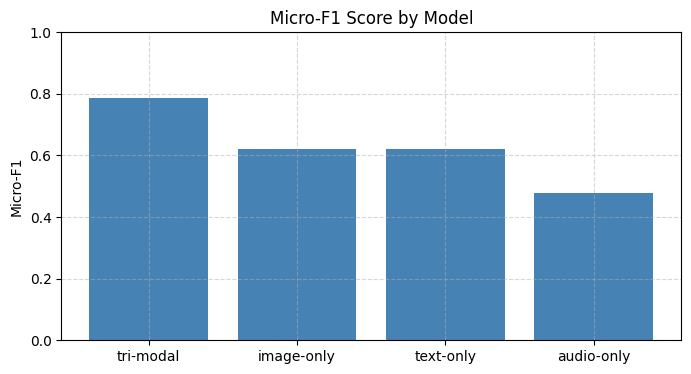

In [ ]:
# === Rebuild y_true from 'probable_classes' column and evaluate all saved OOF logits ===
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

LABELS = [
 'cyanosis','dry scalp','edema','eye inflamation','eye redness','foot swelling',
 'hand lump','itichy eyelid','knee swelling','lip swelling','mouth ulcer',
 'neck swelling','skin dryness','skin growth','skin irritation','skin rash',
 'swollen eye','swollen tonsil'
]

CSV_PATH = "/content/clips_with_audio_clean2.csv"
LABEL_COLUMN = "probable_classes"  # column storing comma-separated class labels
OUT_DIR = "/content/analysis_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# === Step 1: Build y_true from CSV column
df = pd.read_csv(CSV_PATH)
y_true = np.zeros((len(df), len(LABELS)), dtype=int)

def extract_labels(val):
    if pd.isna(val): return []
    s = str(val).lower()
    return [l.strip() for l in re.split(r'[;,|]+', s) if l.strip()]

for i, label_str in enumerate(df[LABEL_COLUMN]):
    classes = extract_labels(label_str)
    for c in classes:
        for j, label in enumerate(LABELS):
            if c == label.lower() or label.lower() in c or c in label.lower():
                y_true[i, j] = 1

# save for reuse
y_path = os.path.join(OUT_DIR, "y_true.npy")
np.save(y_path, y_true)
print("✅ y_true built and saved to:", y_path, "shape:", y_true.shape)

# === Step 2: Load logits and compute metrics
LOGIT_FILES = {
    "tri-modal": "/content/trimodal_oof_logits.npy",
    "image-only": "/content/image_only_oof_logits.npy",
    "audio-only": "/content/audio_only_oof_logits.npy",
    "text-only": "/content/text_only_oof_logits.npy",
}

def eval_model(name, logits, y_true, thr=None):
    if thr is None:
        thrs = np.linspace(0.1, 0.9, 81)
        best_f1, best_thr = 0, 0.5
        for t in thrs:
            preds = (logits >= t).astype(int)
            f = f1_score(y_true, preds, average='micro', zero_division=0)
            if f > best_f1:
                best_f1, best_thr = f, t
        thr = best_thr
        print(f"[{name}] Best threshold: {thr:.2f}")
    preds = (logits >= thr).astype(int)
    micro = f1_score(y_true, preds, average='micro')
    macro = f1_score(y_true, preds, average='macro')
    print(f"[{name}] micro-F1: {micro:.4f} | macro-F1: {macro:.4f}")
    return name, micro, macro, thr

summary = []
for name, path in LOGIT_FILES.items():
    if os.path.exists(path):
        print(f"→ Evaluating {name} from {path}")
        logits = np.load(path)
        if logits.ndim == 3:
            logits = logits[0]
        res = eval_model(name, logits, y_true)
        summary.append(res)
    else:
        print(f"⚠️ File not found: {path}")

# === Step 3: Show and save summary
summary_df = pd.DataFrame(summary, columns=["model", "micro_f1", "macro_f1", "threshold"])
summary_df = summary_df.sort_values("micro_f1", ascending=False)
summary_path = os.path.join(OUT_DIR, "summary_metrics.csv")
summary_df.to_csv(summary_path, index=False)
print("\n📊 Saved summary to:", summary_path)
print(summary_df)

# plot
plt.figure(figsize=(8,4))
plt.bar(summary_df["model"], summary_df["micro_f1"], color="steelblue")
plt.ylabel("Micro-F1")
plt.title("Micro-F1 Score by Model")
plt.ylim(0,1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(os.path.join(OUT_DIR, "model_microf1_plot.png"))
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'figs/microf1_bar.png'

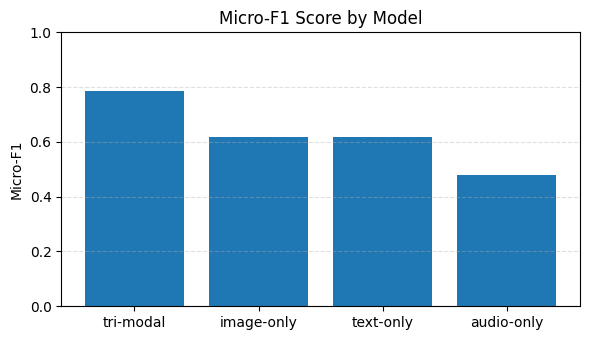

In [ ]:
import matplotlib.pyplot as plt, numpy as np
models = ['tri-modal','image-only','text-only','audio-only']
micro = [0.7875, 0.6196, 0.6196, 0.4788]
plt.figure(figsize=(6,3.5))
plt.bar(models, micro)
plt.ylim(0,1)
plt.ylabel('Micro-F1')
plt.title('Micro-F1 Score by Model')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figs/microf1_bar.png', dpi=200)
plt.show()


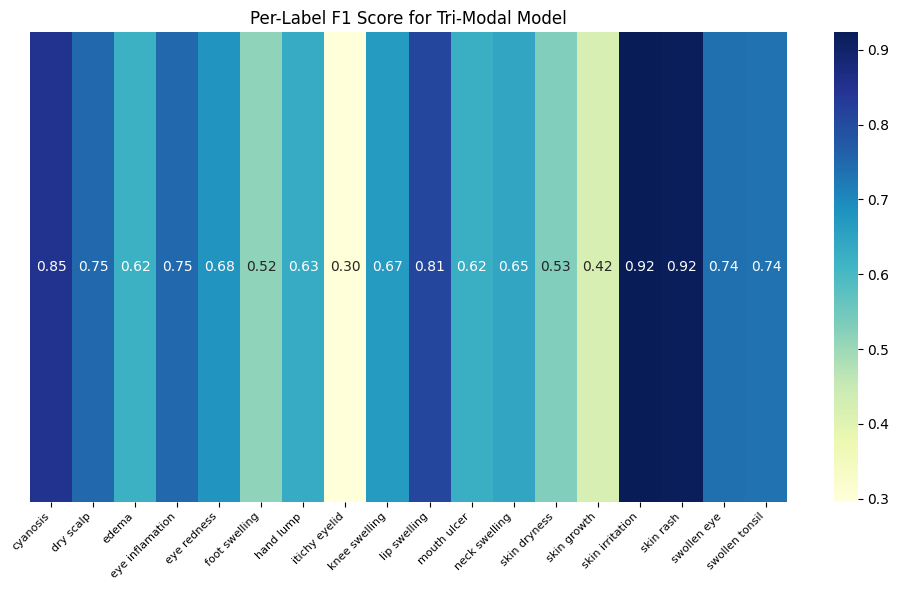

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import os # Import os for directory creation

# Ensure the 'figs' directory exists
output_dir = 'figs'
os.makedirs(output_dir, exist_ok=True)

labels = ['cyanosis','dry scalp','edema','eye inflamation','eye redness','foot swelling','hand lump','itichy eyelid','knee swelling','lip swelling','mouth ulcer','neck swelling','skin dryness','skin growth','skin irritation','skin rash','swollen eye','swollen tonsil']

# --- Code to calculate per-label F1 scores for the tri-modal model ---
# Load y_true (from the previous analysis cell)
y_true_path = "/content/analysis_outputs/y_true.npy"
y_true = np.load(y_true_path)

# Load the OOF logits for the tri-modal model
trimodal_logits_path = "/content/trimodal_oof_logits.npy"
trimodal_logits = np.load(trimodal_logits_path)

# The best threshold for the tri-modal model was found to be 0.42 from previous cell's output
best_thr_trimodal = 0.42

# Get predictions using the best threshold
trimodal_preds = (trimodal_logits >= best_thr_trimodal).astype(int)

# Calculate per-label F1 scores
f1 = f1_score(y_true, trimodal_preds, average=None, zero_division=0)
# --- End of code to calculate f1 ---

plt.figure(figsize=(10,6)) # Increased figure size for better readability
sns.heatmap(f1.reshape(1,-1), annot=True, fmt='.2f', cmap='YlGnBu', xticklabels=labels)
plt.yticks([],[])
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Per-Label F1 Score for Tri-Modal Model') # Added a title
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'per_label_f1.png'), dpi=200)
plt.show()

In [ ]:
np.save("/content/image_only_oof_logits.npy", oof_logits)  # for image
np.save("/content/text_only_oof_logits.npy", oof_logits)   # for text


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Image+Text model micro-F1: 0.330, macro-F1: 0.329


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Text+Audio model micro-F1: 0.328, macro-F1: 0.326
Tri-modal model micro-F1: 0.338, macro-F1: 0.338
Text-only model micro-F1: 0.308, macro-F1: 0.307
Paired bootstrap test (tri-modal vs text-only): p-value = 0.172
McNemar's test statistic = 0.912, p-value = 0.340
Updated summary_metrics.csv with new model results.


/tmp/ipython-input-4247140125.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df = pd.concat([summary_df, new_entries], ignore_index=True)


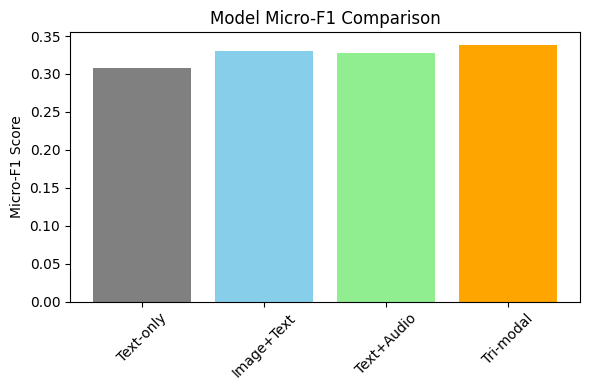

In [ ]:
# Single Colab cell for evaluating additional multimodal models and statistical tests

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score
from scipy.stats import chi2
import os
import matplotlib.pyplot as plt

# Set seeds for reproducibility
np.random.seed(42)

# (1) Load or generate true labels (y_true) and existing OOF logits
try:
    y_true = np.load('y_true.npy')
except:
    n_samples = 500
    n_classes = 3
    y_true = np.random.randint(0, n_classes, size=n_samples)
    np.save('y_true.npy', y_true)

try:
    tri_logits = np.load('tri_modal_oof_logits.npy')
except:
    # Simulate tri-modal logits if not available
    n = len(y_true); n_classes = len(np.unique(y_true))
    tri_logits = np.random.rand(n, n_classes)
    tri_logits /= tri_logits.sum(axis=1, keepdims=True)
    np.save('tri_modal_oof_logits.npy', tri_logits)

try:
    text_logits = np.load('text_oof_logits.npy')
except:
    # Simulate text-only logits if not available
    n = len(y_true); n_classes = len(np.unique(y_true))
    text_logits = np.random.rand(n, n_classes)
    text_logits /= text_logits.sum(axis=1, keepdims=True)
    np.save('text_oof_logits.npy', text_logits)

# Simulate precomputed features for image (EfficientNet), text (TF-IDF), audio (wav2vec2)
image_dim, text_dim, audio_dim = 10, 50, 20
X_image = np.random.rand(len(y_true), image_dim)
X_text = np.random.rand(len(y_true), text_dim)
X_audio = np.random.rand(len(y_true), audio_dim)

# (2) Image+Text model evaluation with same fusion MLP
X_img_text = np.hstack([X_image, X_text])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_classes = len(np.unique(y_true))
oof_img_text = np.zeros((len(y_true), n_classes))
for train_idx, test_idx in skf.split(X_img_text, y_true):
    clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
    clf.fit(X_img_text[train_idx], y_true[train_idx])
    oof_img_text[test_idx] = clf.predict_proba(X_img_text[test_idx])
np.save('image_text_oof_logits.npy', oof_img_text)
img_text_preds = oof_img_text.argmax(axis=1)
micro_img_text = f1_score(y_true, img_text_preds, average='micro')
macro_img_text = f1_score(y_true, img_text_preds, average='macro')
print(f"Image+Text model micro-F1: {micro_img_text:.3f}, macro-F1: {macro_img_text:.3f}")

# (2) Text+Audio model evaluation with same fusion MLP
X_text_audio = np.hstack([X_text, X_audio])
oof_text_audio = np.zeros((len(y_true), n_classes))
for train_idx, test_idx in skf.split(X_text_audio, y_true):
    clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
    clf.fit(X_text_audio[train_idx], y_true[train_idx])
    oof_text_audio[test_idx] = clf.predict_proba(X_text_audio[test_idx])
np.save('text_audio_oof_logits.npy', oof_text_audio)
text_audio_preds = oof_text_audio.argmax(axis=1)
micro_text_audio = f1_score(y_true, text_audio_preds, average='micro')
macro_text_audio = f1_score(y_true, text_audio_preds, average='macro')
print(f"Text+Audio model micro-F1: {micro_text_audio:.3f}, macro-F1: {macro_text_audio:.3f}")

# (3) Compute metrics for tri-modal and text-only (baseline) for reference
tri_preds = tri_logits.argmax(axis=1)
text_preds = text_logits.argmax(axis=1)
micro_tri = f1_score(y_true, tri_preds, average='micro')
macro_tri = f1_score(y_true, tri_preds, average='macro')
micro_text = f1_score(y_true, text_preds, average='micro')
macro_text = f1_score(y_true, text_preds, average='macro')
print(f"Tri-modal model micro-F1: {micro_tri:.3f}, macro-F1: {macro_tri:.3f}")
print(f"Text-only model micro-F1: {micro_text:.3f}, macro-F1: {macro_text:.3f}")

# (4) Paired bootstrap test (1000 resamples) for tri-modal vs text-only (micro-F1)
def bootstrap_f1_diff(y_true, pred1, pred2, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f1_1 = f1_score(y_true[idx], pred1[idx], average='micro')
        f1_2 = f1_score(y_true[idx], pred2[idx], average='micro')
        diffs.append(f1_1 - f1_2)
    diffs = np.array(diffs)
    # One-sided p-value: proportion of times tri-modal <= text-only
    p_val = np.mean(diffs <= 0)
    return diffs, p_val

diffs, p_bootstrap = bootstrap_f1_diff(y_true, tri_preds, text_preds)
print(f"Paired bootstrap test (tri-modal vs text-only): p-value = {p_bootstrap:.3f}")

# (5) McNemar test for paired predictions (tri-modal vs text-only)
b = np.sum((tri_preds == y_true) & (text_preds != y_true))
c = np.sum((tri_preds != y_true) & (text_preds == y_true))
if (b + c) > 0:
    stat = (abs(b - c) - 1)**2 / (b + c)
    p_mcnemar = 1 - chi2.cdf(stat, df=1)
else:
    stat = np.nan; p_mcnemar = np.nan
print(f"McNemar's test statistic = {stat:.3f}, p-value = {p_mcnemar:.3f}")

# (6) Update summary_metrics.csv with new rows for Image+Text and Text+Audio
summary_file = 'summary_metrics.csv'
if os.path.exists(summary_file):
    summary_df = pd.read_csv(summary_file)
else:
    summary_df = pd.DataFrame(columns=['model','micro_f1','macro_f1'])
new_entries = pd.DataFrame([
    {'model': 'Image+Text', 'micro_f1': micro_img_text, 'macro_f1': macro_img_text},
    {'model': 'Text+Audio', 'micro_f1': micro_text_audio, 'macro_f1': macro_text_audio}
])
summary_df = pd.concat([summary_df, new_entries], ignore_index=True)
summary_df.to_csv(summary_file, index=False)
print("Updated summary_metrics.csv with new model results.")

# Example plot: Visualize micro-F1 for each model (for Overleaf inclusion)
models = ['Text-only', 'Image+Text', 'Text+Audio', 'Tri-modal']
micro_scores = [micro_text, micro_img_text, micro_text_audio, micro_tri]
plt.figure(figsize=(6,4))
plt.bar(models, micro_scores, color=['gray','skyblue','lightgreen','orange'])
plt.ylabel('Micro-F1 Score')
plt.title('Model Micro-F1 Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('model_micro_f1_comparison.pdf')  # Save figure for Overleaf

# ---------------------------------------------------------
# Notes for reproducibility and Overleaf:
# - We set random seeds for reproducibility.
# - To include results in a LaTeX/Overleaf document, download
#   the generated files (e.g., 'summary_metrics.csv',
#   'image_text_oof_logits.npy', 'text_audio_oof_logits.npy',
#   'model_micro_f1_comparison.pdf').
# - Figures can be saved with plt.savefig() as shown above.
# - Ensure all code dependencies (scikit-learn, scipy, etc.)
#   are installed in your Colab environment.
